# Simulation of a positron-induced Muon Source

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

<center>
    <img src="Feynman_Diagram.svg" width="400" style="filter: invert(100%)">
</center>

\begin{split}
iM &= \overline{U}_{r'}(k) (ie\gamma^{\mu}) V_{s'}(k') \left( \frac{-i\eta_{\mu\nu}}{s} \right) \overline{V}_{s}(p') (ie\gamma^{\nu}) U_{r}(p) \\
   &= \frac{ie^2}{s} (\overline{U}_{r'}(k) \gamma^{\mu} V_{s'}(k') \overline{V}_{s}(p') \gamma_{\mu} U_{r}(p))
\end{split}


$\providecommand{\slashed}[1]{#1 \kern-0.5em /}$
$|\overline{M}|^2 = \frac{1}{4} \sum_{spins} M M^* = \frac{e^4}{4 s^2} Tr((\slashed{k}'-m) \gamma^\nu (\slashed{k}+m) \gamma^\mu) Tr((\slashed{p}+m) \gamma_\nu (\slashed{p}'-m) \gamma_\mu)$

$Tr((\slashed{k}'-m) \gamma^\nu (\slashed{k}+m) \gamma^\mu) = 4 (k^\mu k'^\nu + k^\nu k'^\mu - (k \cdot k' + m_\mu^2) \eta^{\nu\mu})$

$Tr((\slashed{p}+m) \gamma_\nu (\slashed{p}'+m) \gamma_\mu) = 4 (p_\mu p'_\nu + p_\nu p'_\mu - (p \cdot p' + m_e^2) \eta_{\nu\mu})$


(Note: $m_\mu^2$ is not Einstein indexing)

$|\overline{M}|^2 = \frac{8 e^4}{s^2} ((k \cdot p)(k' \cdot p') + (k \cdot p')(k' \cdot p) + m_e^2 (k \cdot k') + m_\mu^2 (p \cdot p') + 2 m_e^2 m_\mu^2)$

$m_e$ negligible ?

Kinematic

$ s = (p + p')^2 = 2 m_e^2 + 2 p \cdot p' \Rightarrow p \cdot p' = \frac{s}{2} - m_e^2 $

$ k \cdot k' = \frac{s}{2} - m_\mu^2$

$ p \cdot k = $

$ p \cdot k' = $

If $m_e = 0$

$\left( \frac{d\sigma}{d\omega} \right)_{CM} = \frac{e^4}{64 \pi^2 s} \sqrt{\left(1 - \frac{4 m_\mu^2}{s} \right)} \left(\left(1 + \frac{4 m_\mu^2}{s} \right) + \left(1 - \frac{4 m_\mu^2}{s} \right) \cos{\theta}^2 \right) $

$(p, 0, 0, p)$

$p_\mu p^\mu = m_\gamma^2 = 0 = E^2 - p^2$

Threshold sqrt(s) is: 0.211316751 GeV
sqrt(s) fixed at: 0.23244842610000002 GeV,  10.0 % above threshold
Beam energy:  52.86874707233067 GeV


<function matplotlib.pyplot.show(close=None, block=None)>

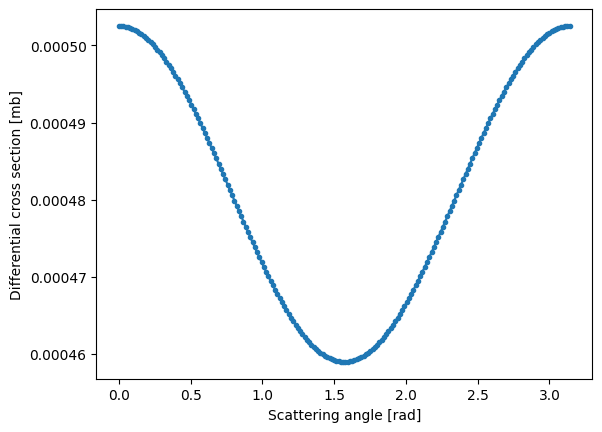

In [15]:
mass_e = 0.00051099895069 # GeV
mass_mu = 0.1056583755 # GeV
alpha = 1/137
conversion_factor = 0.3894      # this is equal to (hbar * c)^2 expressed in mbarn * GeV


def cross_section(s, theta):
    ratio = 4 * mass_mu**2 / s
    return ((np.pi * alpha**2 )/ (2 * s)) * np.sqrt(1 - ratio) * (1 + ratio + (1 - ratio) * np.cos(theta)**2)

def cross_section_norm(s, cos):     # check normalization
    ratio = 4 * mass_mu**2 / s
    beta = np.sqrt(1 - ratio)
    return 3 / (4*(3 - beta**2)) * (1 + cos**2 + (1 - beta**2) * (1 - cos**2))

E_threshold = 2*mass_mu     # threshold
print('Threshold sqrt(s) is:', E_threshold, 'GeV')
E_percent_increase = 0.1
E_fixed = E_threshold * (1 + E_percent_increase)    # should be greater than 4 mass_mu**2
print('sqrt(s) fixed at:', E_fixed, 'GeV, ', E_percent_increase * 100, r'% above threshold')
s = E_fixed**2

beam_energy = (s - 2 * mass_e**2) / (2 * mass_e)
print('Beam energy: ', beam_energy, 'GeV')

l = np.linspace(0, np.pi, 200, endpoint=True)
plt.plot(l, cross_section(s, l) * conversion_factor, marker=".")
plt.xlabel('Scattering angle [rad]')
plt.ylabel('Differential cross section [mb]')
plt.show

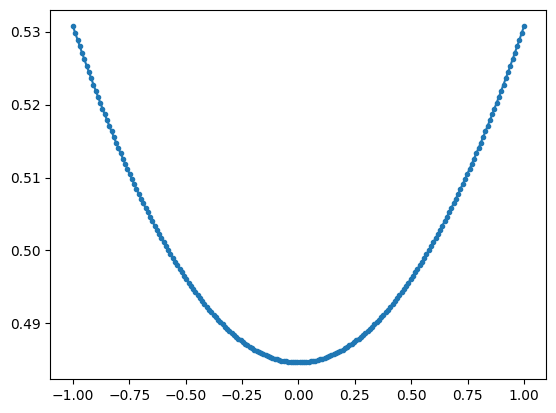

In [16]:
cos_linspace = np.linspace(-1, 1, 200, endpoint=True)
plt.plot(cos_linspace, cross_section_norm(s, cos_linspace), marker=".")


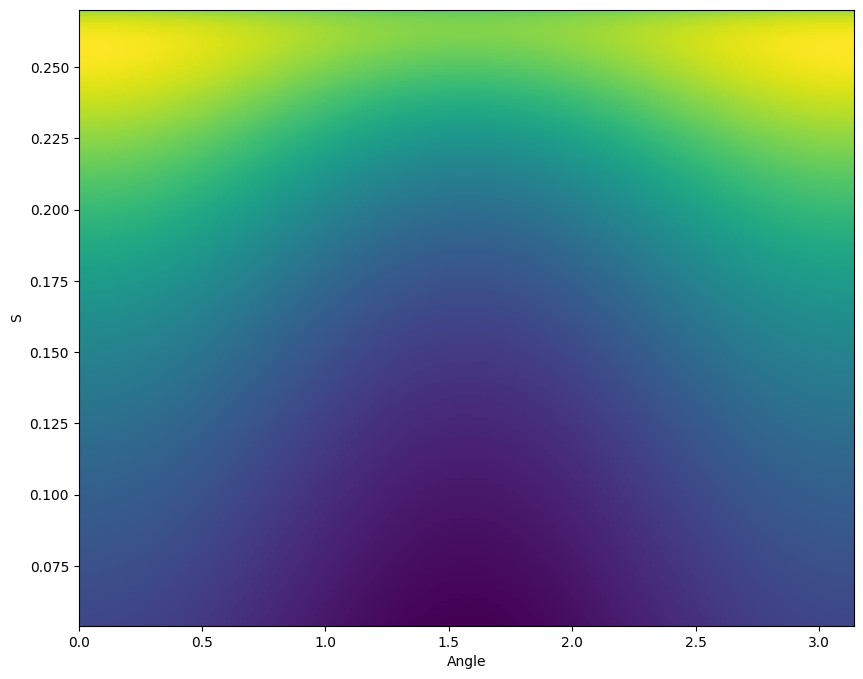

In [17]:
s_space = np.linspace(s, 5 * s, 200, endpoint=True)

xv, yv = np.meshgrid(l, s_space)

plt.figure(figsize=(10, 8))
plt.imshow(cross_section(yv, xv), extent=[0, np.pi, s, 5*s], aspect='auto')
plt.xlabel("Angle")
plt.ylabel("S")
plt.show()

94194


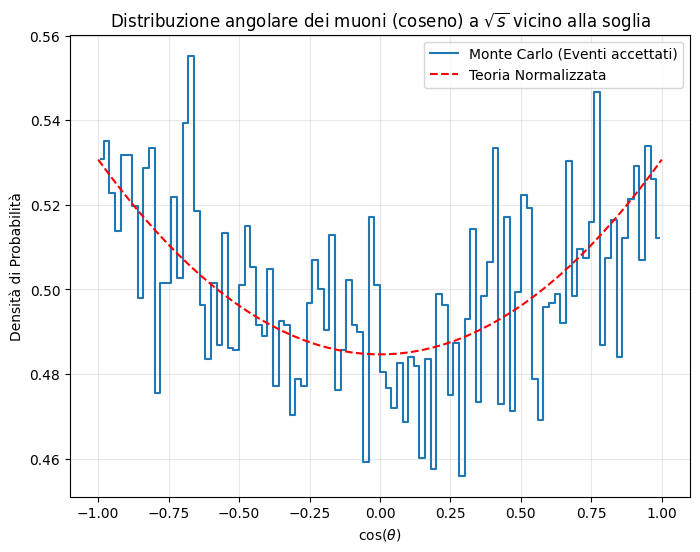

In [ ]:
n = 100000
u = np.random.uniform(-1, 1, n)
r = np.random.uniform(0, cross_section_norm(s, 1), n)
v = u[r < cross_section_norm(s, u)]
print(len(v))

# Plot di confronto
plt.figure(figsize=(8, 6))

# Istogramma del Monte Carlo (Normalizzato con density=True)
hist, bin_edges = np.histogram(v, bins=100, density=True)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2.
plt.step(bin_centers, hist, where='mid', label="Monte Carlo (Eventi accettati)")

# Curva teorica normalizzata
cos_range = np.linspace(-1, 1, 50)
plt.plot(cos_range, cross_section_norm(s, cos_range), 'r--', label="Teoria Normalizzata")

plt.xlabel(r"$\cos(\theta)$")
plt.ylabel("Densità di Probabilità")
plt.title(r"Distribuzione angolare dei muoni (coseno) a $\sqrt{s}$ vicino alla soglia")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

$ E_{e^+}=\frac{s-2m_e^2}{2m_e}$

$p_{e^+}=\sqrt{E_{e^+}^2-m_e^2}$

$\beta=\frac{p_{e^+}}{E_{e^+}+m_e}=\frac{v}{c}$

$\gamma=\frac{E_{e^+}+m_e}{\sqrt {s}}=\frac{1}{\sqrt{1-\beta^2}}$

$p_{\mu}=\sqrt{\frac{s}{4}-m_{\mu}^2}$

$p_{x,CM}=p_{\mu}\sin\theta\cos\phi$

$p_{y,CM}=p_{\mu}\sin\theta\sin\phi$

$p_{z,CM}=p_{\mu}\cos\theta$

$E_{CM}=\frac{\sqrt{s}}{2}$

$ E_{lab} = \gamma (E_{CM}+\beta p_{z,CM})$

$ p_{z,lab} = \gamma(p_{z,CM}+\beta E_{CM})$

$ p_{x,lab} = p_{x,CM}$

$ p_{y,lab} = p_{y,CM}$

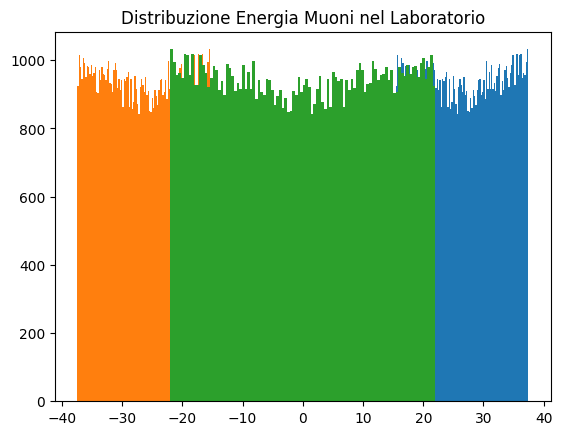

In [19]:
E_pos = (s - 2 * mass_e**2) / (2 * mass_e)
p_pos = np.sqrt(E_pos**2 - mass_e**2)
gamma = (E_pos + mass_e) / np.sqrt(s)
beta = p_pos / (E_pos + mass_e)

phi = np.random.uniform(0, 2*np.pi, len(v))
p_mod = np.sqrt(s/4 - mass_mu**2)
px_cm_1 = p_mod * np.sqrt(1 - v**2) * np.cos(phi)
py_cm_1 = p_mod * np.sqrt(1 - v**2) * np.sin(phi)
pz_cm_1 = p_mod * v
E_cm_1 = np.sqrt(s)/2

px_cm_2 = -1 * p_mod * np.sqrt(1 - v**2) * np.cos(phi)
py_cm_2 = -1 * p_mod * np.sqrt(1 - v**2) * np.sin(phi)
pz_cm_2 = -1 * p_mod * v
E_cm_2 = np.sqrt(s)/2

px_lab_1=px_cm_1
py_lab_1=py_cm_1
pz_lab_1 = gamma * (pz_cm_1 + beta * E_cm_1)
E_lab_1 = gamma * (E_cm_1 + beta * pz_cm_1)

px_lab_2=px_cm_2
py_lab_2=py_cm_2
pz_lab_2 = gamma * (pz_cm_2 + beta * E_cm_2)
E_lab_2 = gamma * (E_cm_2 + beta * pz_cm_2)

plt.hist(E_lab_1, bins=100)
plt.hist(-1.0* E_lab_2, bins=100)
plt.hist(E_lab_2 - E_lab_1, bins=100)
#plt.scatter(E_lab_1, E_lab_2, marker=".")
plt.title("Distribuzione Energia Muoni nel Laboratorio")
plt.show()


(array([  146.,   386.,   613.,   804.,   974.,  1195.,  1419.,  1775.,
         1866.,  2117.,  2300.,  2565.,  2691.,  2976.,  3146.,  3541.,
         3699.,  4011.,  4343.,  4756.,  5138.,  5720.,  6977.,  9033.,
        21936.]),
 array([1.11465367e-05, 9.12937127e-05, 1.71440889e-04, 2.51588065e-04,
        3.31735241e-04, 4.11882417e-04, 4.92029593e-04, 5.72176769e-04,
        6.52323945e-04, 7.32471121e-04, 8.12618297e-04, 8.92765473e-04,
        9.72912649e-04, 1.05305982e-03, 1.13320700e-03, 1.21335418e-03,
        1.29350135e-03, 1.37364853e-03, 1.45379570e-03, 1.53394288e-03,
        1.61409006e-03, 1.69423723e-03, 1.77438441e-03, 1.85453158e-03,
        1.93467876e-03, 2.01482594e-03]),
 <BarContainer object of 25 artists>)

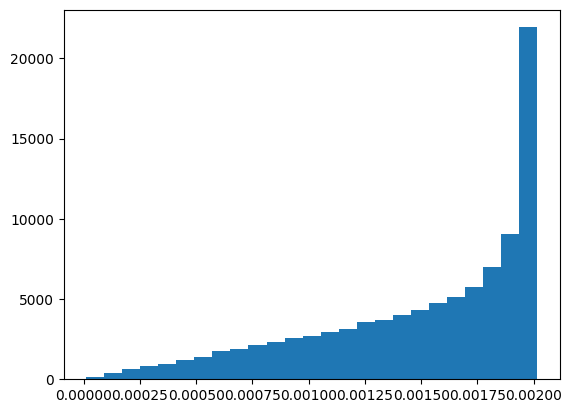

In [20]:
plt.hist(np.arccos(pz_lab_1 / np.sqrt(px_cm_1 ** 2 + py_cm_1 ** 2 + pz_lab_1 ** 2)), bins=25)

(array([  156.,   311.,   567.,   839.,  1034.,  1213.,  1494.,  1702.,
         1892.,  2082.,  2320.,  2529.,  2649.,  2950.,  3193.,  3553.,
         3675.,  4158.,  4300.,  4779.,  5146.,  5955.,  7018.,  8840.,
        21772.]),
 array([1.12054850e-05, 9.13503030e-05, 1.71495121e-04, 2.51639939e-04,
        3.31784757e-04, 4.11929575e-04, 4.92074393e-04, 5.72219212e-04,
        6.52364030e-04, 7.32508848e-04, 8.12653666e-04, 8.92798484e-04,
        9.72943302e-04, 1.05308812e-03, 1.13323294e-03, 1.21337776e-03,
        1.29352257e-03, 1.37366739e-03, 1.45381221e-03, 1.53395703e-03,
        1.61410185e-03, 1.69424666e-03, 1.77439148e-03, 1.85453630e-03,
        1.93468112e-03, 2.01482594e-03]),
 <BarContainer object of 25 artists>)

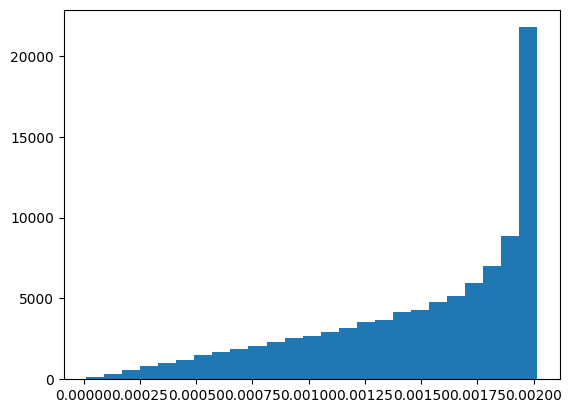

In [21]:
plt.hist(np.arccos(pz_lab_2 / np.sqrt(px_cm_2 ** 2 + py_cm_2 ** 2 + pz_lab_2 ** 2)), bins=25)

In [22]:
data = np.column_stack([E_lab_1, px_lab_1, py_lab_1, pz_lab_1, E_lab_2, px_lab_2, py_lab_2, pz_lab_2])

np.savetxt("muons_lab.txt", data)

column_names = ["E_mu+_lab", "px_mu+_lab", "py_mu+_lab", "pz_mu+_lab", "E_mu-_lab", "px_mu-_lab", "py_mu-_lab", "pz_mu-_lab"]
df = pd.read_csv("muons_lab.txt",sep=r'\s+', names=column_names)

df

,E_mu+_lab,px_mu+_lab,py_mu+_lab,pz_mu+_lab,E_mu-_lab,px_mu-_lab,py_mu-_lab,pz_mu-_lab
0,32.638568,-0.007438,0.039307,32.638372,20.230691,0.007438,-0.039307,20.230375
1,27.753865,-0.038706,0.028506,27.753622,25.115394,0.038706,-0.028506,25.115125
2,21.540030,0.027766,0.033321,21.539727,31.329228,-0.027766,-0.033321,31.329020
3,22.486354,0.038786,0.023209,22.486060,30.382904,-0.038786,-0.023209,30.382687
4,16.737178,0.021289,0.008560,16.736829,36.132080,-0.021289,-0.008560,36.131918
...,...,...,...,...,...,...,...,...
94122,31.690517,0.003266,0.042423,31.690312,21.178741,-0.003266,-0.042423,21.178435
94123,21.040429,-0.041317,0.008647,21.040121,31.828829,0.041317,-0.008647,31.828626
94124,25.797114,-0.031355,0.036788,25.796853,27.072144,0.031355,-0.036788,27.071894
94125,15.883070,0.011862,-0.007172,15.882712,36.986188,-0.011862,0.007172,36.986035


Text(0, 0.5, '$\\phi$ [rad]')

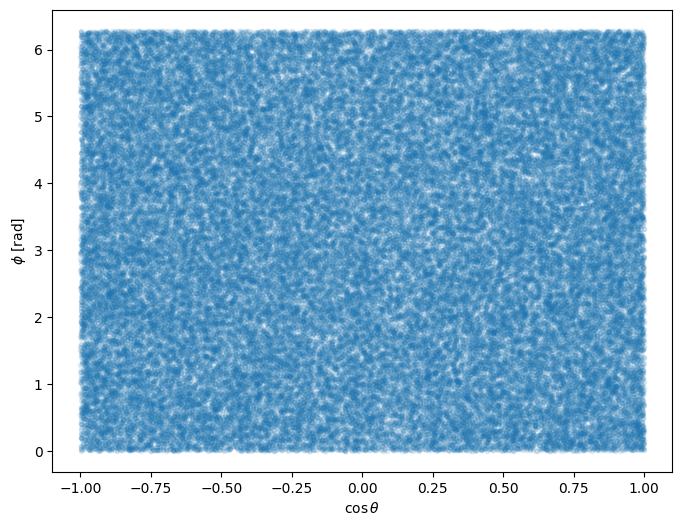

In [23]:
plt.figure(figsize=(8, 6))

plt.scatter(v, phi, marker=".", alpha=0.1)
plt.xlabel(r"$\cos{\theta}$")
plt.ylabel(r"$\phi$ [rad]")

Text(0, 0.5, '$\\phi$ [rad]')

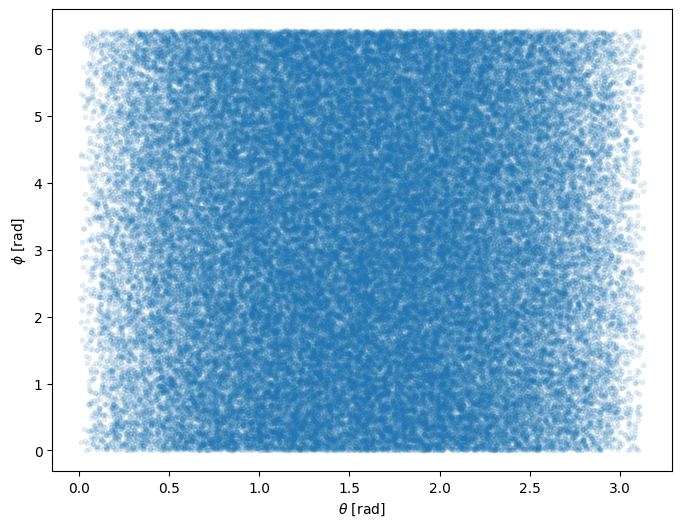

In [24]:
plt.figure(figsize=(8, 6))

plt.scatter(np.arccos(v), phi, marker=".", alpha=0.1)
plt.xlabel(r"$\theta$ [rad]")
plt.ylabel(r"$\phi$ [rad]")

In [25]:
#total cross section integrating over solid angle
cross_section_tot = ((2 * np.pi * alpha**2) / (3 * s)) * beta * (3 - beta**2) * conversion_factor
print('The total cross section is:', cross_section_tot, 'mbarn')

The total cross section is: 0.0016083856965234868 mbarn


In [32]:
# point 6
d = 3                       # cm
rate = 10**6                # Hz

uma = 1.660539e-24          # unitò di massa atomica in g
B = 9.0121831               # atomic weight del berillio in uma
rho = 1.845                 # densità del berillio in g/cm^3
n_be = rho / (uma * B)         # densità atomica del berillio

P = n_be * d * cross_section_tot * 10**(-27)       # convertendo la cross section da mbarn a cm**2
T = 7 * 24 * 3600           # s

E = T * rate * P
weight = E / len(v)
print(E)
print(len(v))

print('The conversion factor is:', weight)

359782.90427444497
94194
The conversion factor is: 3.8195947117061064


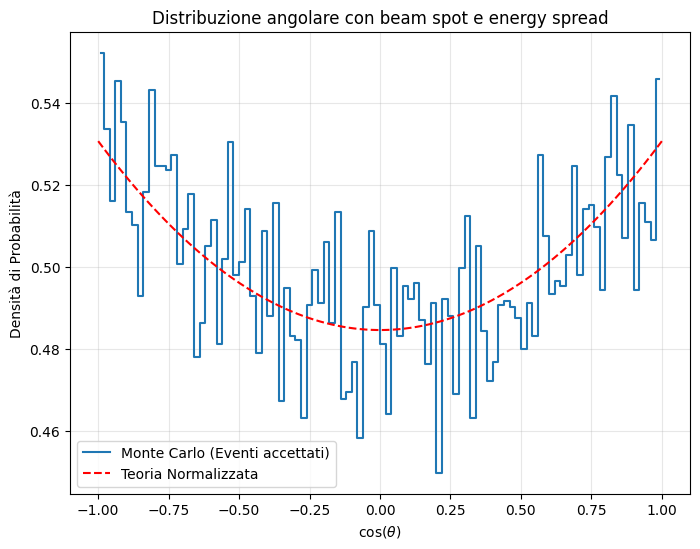

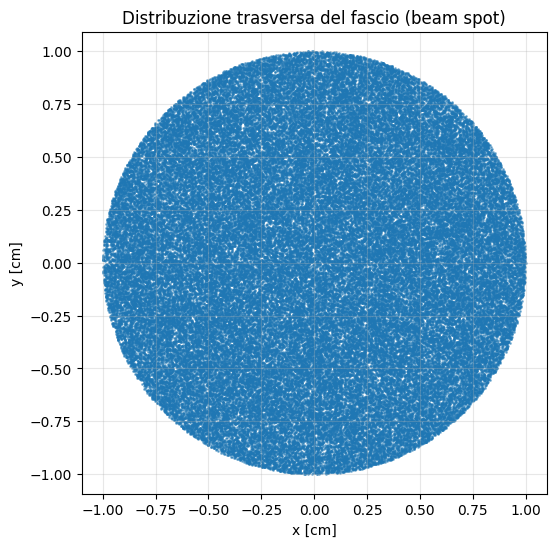

In [ ]:
R = 1.0  
alpha = np.random.uniform(0, 2*np.pi, n)
rho = R * np.sqrt(np.random.uniform(0,1,n))
x = rho * np.cos(alpha)
y = rho * np.sin(alpha)

sigmaE=0.5 #width
E=np.random.normal(beam_energy, sigmaE, n)

m_e = 0.000511  # GeV
s = 2 * m_e * (E + m_e) #in lab frame

u_new = np.random.uniform(-1, 1, n)
r_new = np.random.uniform(0, cross_section_norm(s, 1), n)
v_new = u_new[r_new < cross_section_norm(s, u_new)]


# Plot di confronto
plt.figure(figsize=(8, 6))

# Istogramma del Monte Carlo (Normalizzato con density=True)
hist, bin_edges = np.histogram(v_new, bins=100, density=True)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2.
plt.step(bin_centers, hist, where='mid', label="Monte Carlo (Eventi accettati)")

# Curva teorica normalizzata
s_mean = np.mean(s)#curva teorica “di riferimento”, confronto visivo con la curva teorica serve una singola curva
cos_range = np.linspace(-1, 1, 100)
plt.plot(cos_range, cross_section_norm(s_mean, cos_range), 'r--', label="Teoria Normalizzata")

plt.xlabel(r"$\cos(\theta)$")
plt.ylabel("Densità di Probabilità")
plt.title(r"Distribuzione angolare con beam spot e energy spread")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Plot del beam spot (x,y)
plt.figure(figsize=(6,6))
plt.scatter(x, y, s=1, alpha=0.5)
plt.xlabel("x [cm]")
plt.ylabel("y [cm]")
plt.title("Distribuzione trasversa del fascio (beam spot)")
plt.axis("equal")
plt.grid(alpha=0.3)
plt.show()

In [ ]:
# Energia soglia per generare muoni
E_th = ((2*mass_mu)**2 - 2 * m_e**2) / (2*m_e)  # GeV

# Parametri target
L = 6.0   # lunghezza target in cm (usato nel paper del prof)
X0 = 35.3 # lunghezza di radiazione del Be in cm
E0 = E_th * np.exp(L / X0)
print(f"Nominal beam energy: {E0:.2f} GeV")

z = np.random.uniform(0, L, n_z)  # posizione casuale lungo il target
E_beam = E0 * np.exp(-z / X0)  # energia effettiva al punto z

data = pd.DataFrame({"x_cm": x,"y_cm": y, "z_cm": z,"E_beam_GeV": E_beam})
data.to_csv("simulated_muon_beam.csv", index=False)
data

Nominal beam energy: 51.79 GeV


,x_cm,y_cm,z_cm,E_beam_GeV
0,0.027540,0.728000,0.331354,51.304210
1,0.589887,0.642400,4.935333,45.030879
2,-0.516750,-0.291845,4.506368,45.581432
3,-0.039102,-0.378575,3.872687,46.407066
4,-0.169174,0.413296,4.197634,45.981837
...,...,...,...,...
99995,-0.763570,-0.159020,5.738454,44.017934
99996,-0.485899,-0.252525,5.794756,43.947784
99997,0.924916,0.323153,3.394933,47.039415
99998,0.706897,-0.596424,1.645865,49.428864


In [43]:
# Genera angoli nel CM usando s_z
s_z = 2 * m_e**2 + 2 * m_e * E_beam

n_z = 1000000
u_z = np.random.uniform(-1, 1, n_z)
r_z = np.random.uniform(0, cross_section_norm(s_z, 1), n_z)
v_z = u_z[r_z < cross_section_norm(s_z, u_z)]

plt.figure(figsize=(8, 6))

# Istogramma del Monte Carlo (Normalizzato con density=True)
hist, bin_edges = np.histogram(v_z, bins=100, density=True)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2.
plt.step(bin_centers, hist, where='mid', label="Monte Carlo (Eventi accettati)")

# Curva teorica normalizzata
s_z_mean = np.mean(s_z)
cos_range = np.linspace(-1, 1, 50)
plt.plot(cos_range, cross_section_norm(s_z_mean, cos_range), 'r--', label="Teoria Normalizzata")

plt.xlabel(r"$\cos(\theta)$")
plt.ylabel("Densità di Probabilità")
plt.title(r"Distribuzione angolare dei muoni (coseno) a $\sqrt{s}$ vicino alla soglia")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


# Effettua il Boost nel Lab usando E_z e s_z

ValueError: shape mismatch: objects cannot be broadcast to a single shape.  Mismatch is between arg 0 with shape (1000000,) and arg 2 with shape (100000,).